In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

rng = np.random.default_rng(seed=42)

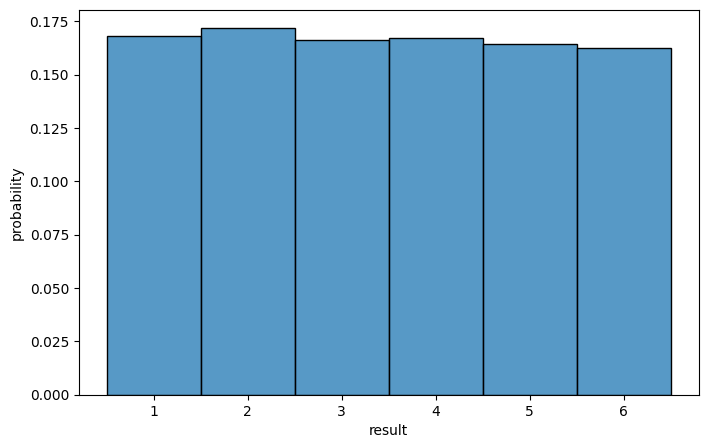

In [2]:
dice_rolls = rng.integers(1, 7, size=10000)
plt.figure(figsize=(8,5))

sns.histplot(
    dice_rolls,
    bins=np.arange(0.5, 7.5, 1),
    discrete=True,
    stat='probability'
)

plt.xlabel("result")
plt.ylabel("probability")
plt.xticks(range(1, 7))

plt.show()

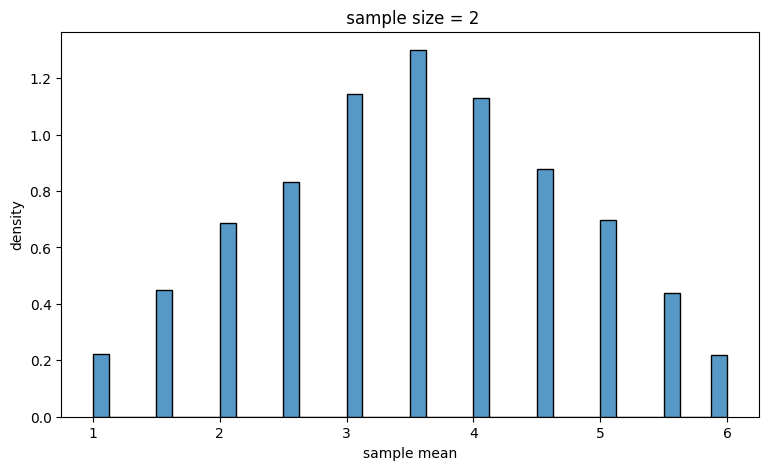

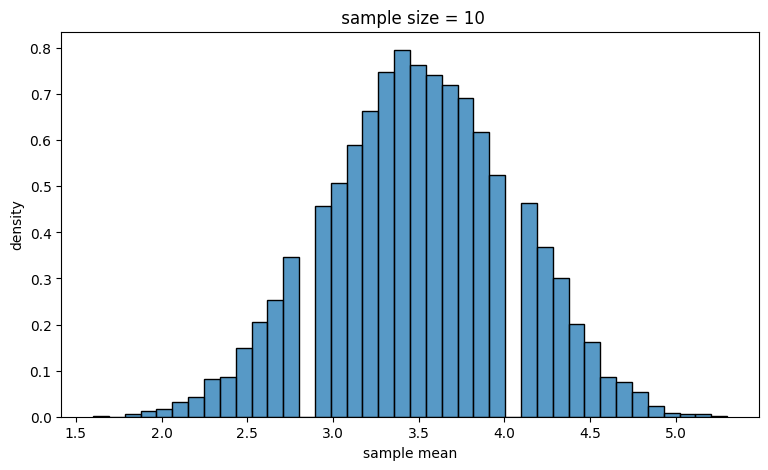

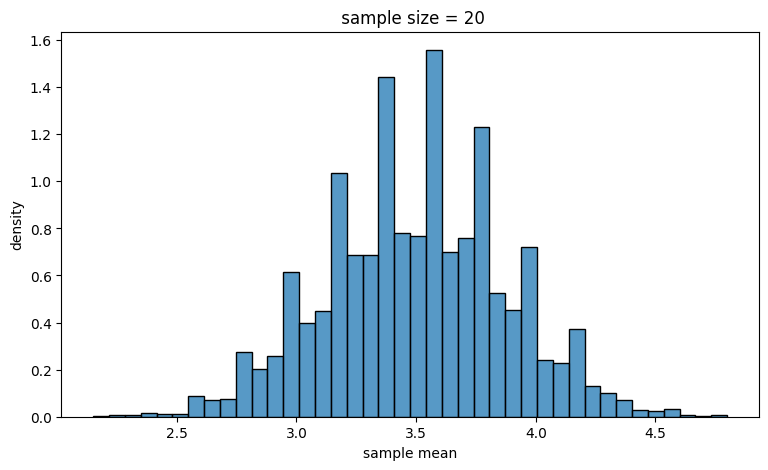

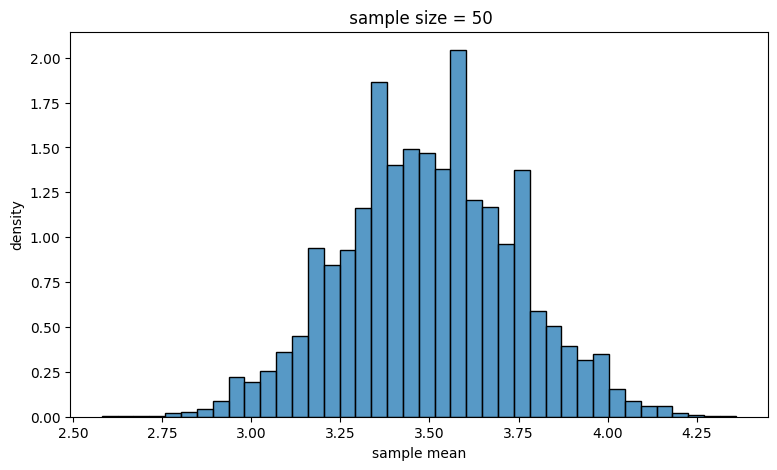

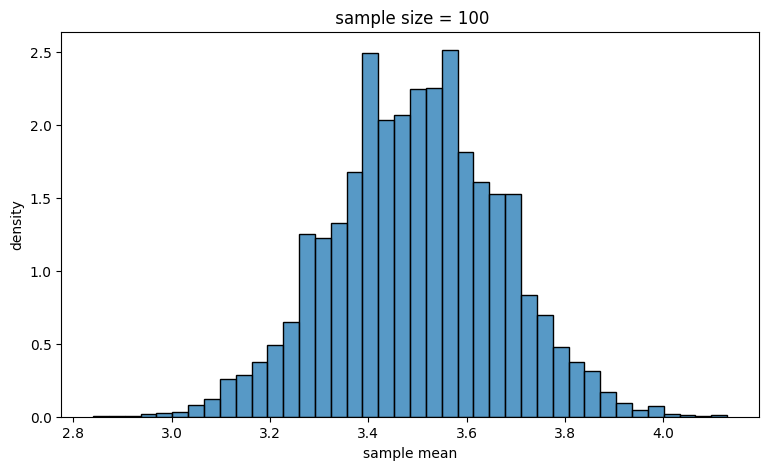

In [3]:
sample_sizes = [2, 10, 20, 50, 100]
samples_num = 10000

for n in sample_sizes:
    samples = rng.integers(1,7,size=(samples_num, n))

    sample_means = samples.mean(axis=1)

    plt.figure(figsize=(9,5))

    sns.histplot(sample_means, bins=40, kde=False, stat='density')

    plt.title(f' sample size = {n}')
    plt.xlabel('sample mean')
    plt.ylabel('density')
    plt.show()

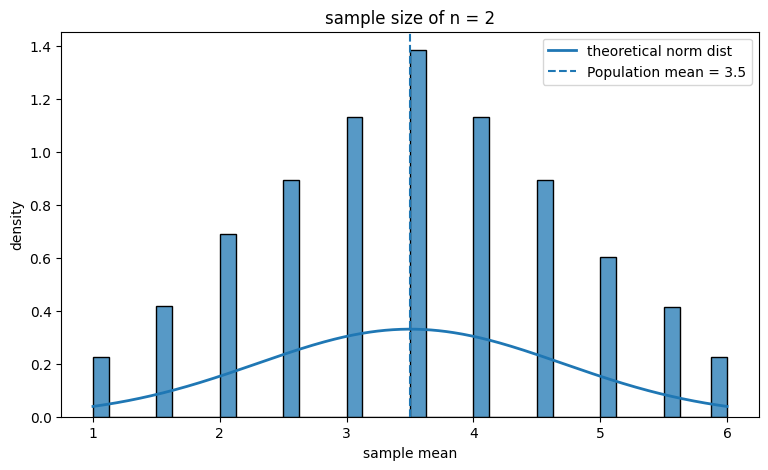

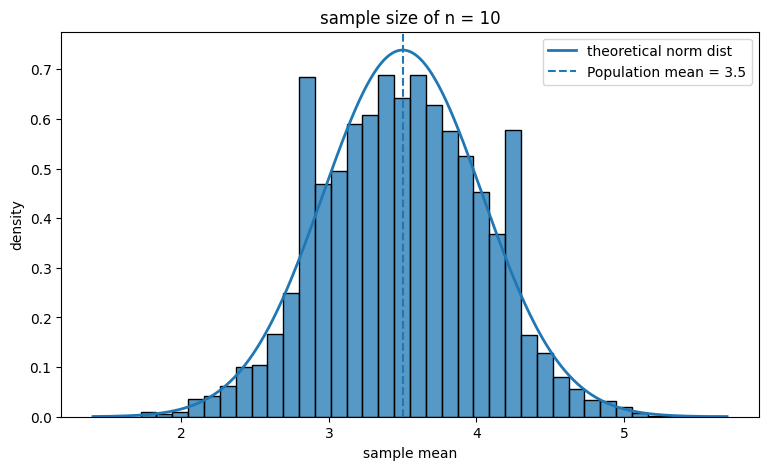

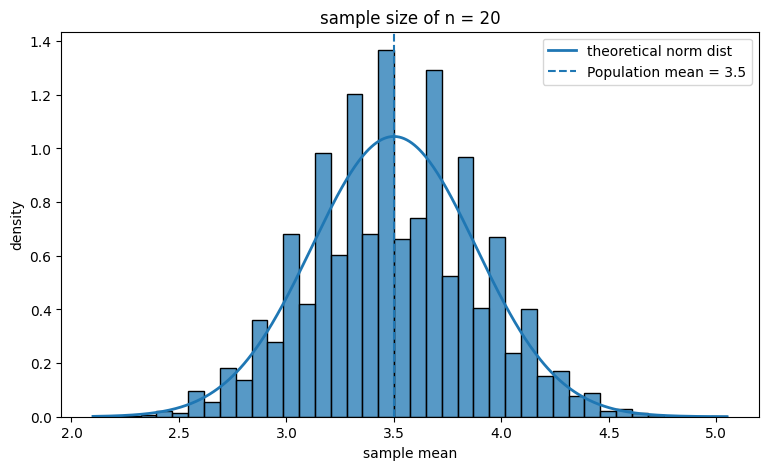

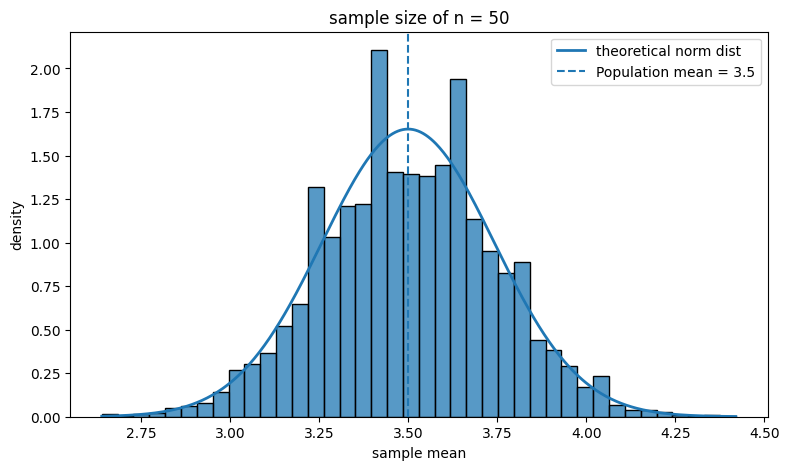

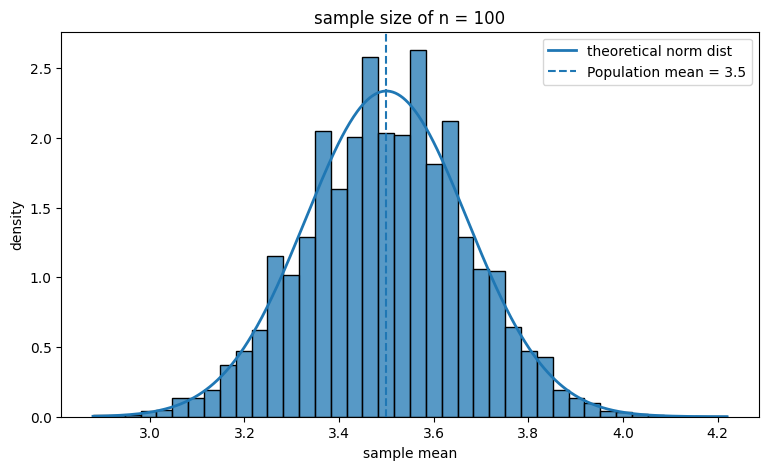

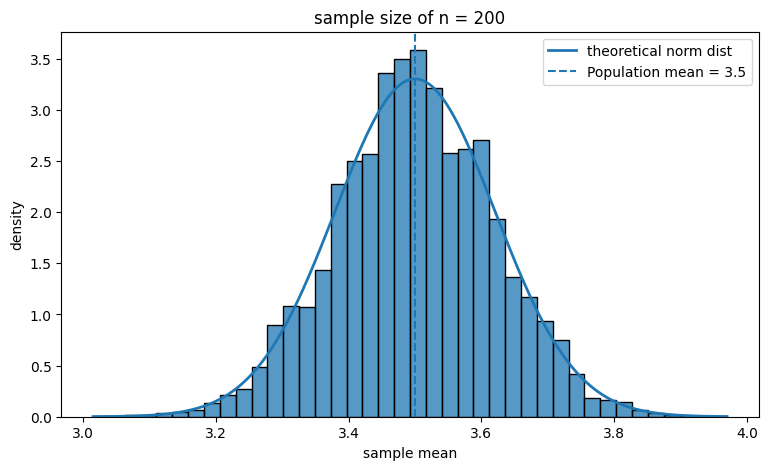

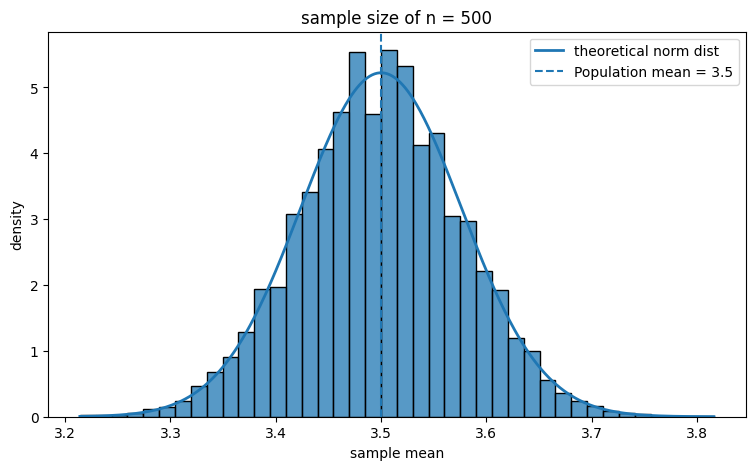

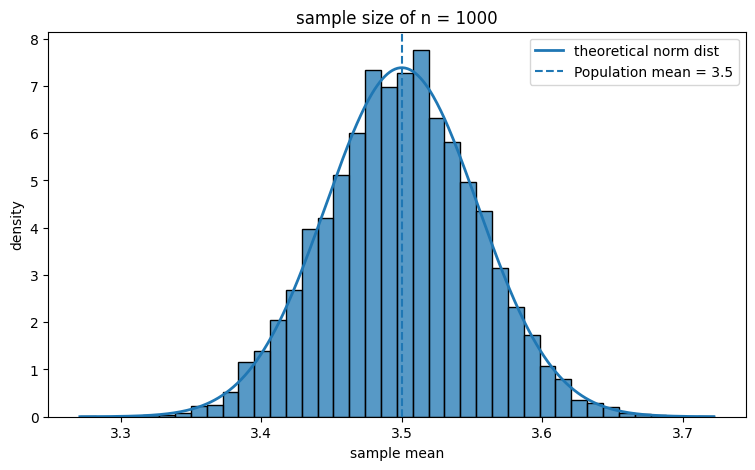

In [4]:
sample_sizes = [2, 10, 20, 50, 100, 200, 500, 1000]
n_samples = 10_000

population_mean = 3.5
population_std = np.sqrt(35 / 12)

for n in sample_sizes:
    samples = rng.integers(1,7, size=(n_samples, n))
    sample_means = samples.mean(axis=1)

    standard_error = population_std / np.sqrt(n)

    x = np.linspace(sample_means.min(), sample_means.max(), 500)

    normal_density = norm.pdf(x, loc=population_mean, scale=standard_error)

    plt.figure(figsize=(9, 5))

    sns.histplot(sample_means, bins=40, stat="density")

    plt.plot(x, normal_density, linewidth=2, label="theoretical norm dist")

    plt.axvline(
        population_mean, linestyle="--", 
        label=f"Population mean = {population_mean}"
    )

    plt.title(f"sample size of n = {n}")
    plt.xlabel("sample mean")
    plt.ylabel("density")
    plt.legend()

    plt.show()

In [6]:
results = list()

for n in sample_sizes:
    samples = rng.integers(1,7,size=(n_samples,n))

    sample_means = samples.mean(axis=1)

    results.append({'sample_size': n,
                    'mean_of_sample_means': sample_means.mean().round(3),
                    'simulated_se': sample_means.std().round(3),
                    'theoretical_se': (population_std / np.sqrt(n)).round(3),
                    'theory_sim_diff': abs(sample_means.std() - (population_std / np.sqrt(n))).round(5)
                   })
results

[{'sample_size': 2,
  'mean_of_sample_means': np.float64(3.504),
  'simulated_se': np.float64(1.208),
  'theoretical_se': np.float64(1.208),
  'theory_sim_diff': np.float64(0.00042)},
 {'sample_size': 10,
  'mean_of_sample_means': np.float64(3.505),
  'simulated_se': np.float64(0.538),
  'theoretical_se': np.float64(0.54),
  'theory_sim_diff': np.float64(0.00161)},
 {'sample_size': 20,
  'mean_of_sample_means': np.float64(3.504),
  'simulated_se': np.float64(0.381),
  'theoretical_se': np.float64(0.382),
  'theory_sim_diff': np.float64(0.00058)},
 {'sample_size': 50,
  'mean_of_sample_means': np.float64(3.497),
  'simulated_se': np.float64(0.241),
  'theoretical_se': np.float64(0.242),
  'theory_sim_diff': np.float64(0.00047)},
 {'sample_size': 100,
  'mean_of_sample_means': np.float64(3.5),
  'simulated_se': np.float64(0.171),
  'theoretical_se': np.float64(0.171),
  'theory_sim_diff': np.float64(0.00015)},
 {'sample_size': 200,
  'mean_of_sample_means': np.float64(3.503),
  'simulate

In [7]:
results_df = pd.DataFrame(results)
results_df.describe()

,sample_size,mean_of_sample_means,simulated_se,theoretical_se,theory_sim_diff
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,235.250000,3.501625,0.348875,0.349250,0.000489
std,350.563526,0.002774,0.383772,0.383987,0.000482
min,2.000000,3.497000,0.054000,0.054000,0.000080
25%,17.500000,3.500000,0.110000,0.109750,0.000225
50%,75.000000,3.501500,0.206000,0.206500,0.000385
75%,275.000000,3.504000,0.420250,0.421500,0.000498
max,1000.000000,3.505000,1.208000,1.208000,0.001610


In [8]:
results_df

,sample_size,mean_of_sample_means,simulated_se,theoretical_se,theory_sim_diff
0,2,3.504,1.208,1.208,0.00042
1,10,3.505,0.538,0.540,0.00161
2,20,3.504,0.381,0.382,0.00058
3,50,3.497,0.241,0.242,0.00047
4,100,3.500,0.171,0.171,0.00015
5,200,3.503,0.121,0.121,0.00008
6,500,3.500,0.077,0.076,0.00025
7,1000,3.500,0.054,0.054,0.00035
